In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded")

All libraries loaded


In [2]:
# Load the dataset
df = pd.read_csv('../data/medicare_data.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

/var/folders/88/vf17w_ms6ndbxhw90bxfnmhw0000gp/T/ipykernel_75213/260226470.py:2: DtypeWarning: Columns (0: Rndrng_Prvdr_State_FIPS, 1: Rndrng_Prvdr_Zip5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/medicare_data.csv')


Shape: (9660647, 28)

Columns:
['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt']


In [3]:
# Reload cleanly with fix
df = pd.read_csv('../data/medicare_data.csv', 
                 low_memory=False,
                 dtype={'Rndrng_Prvdr_State_FIPS': str, 
                        'Rndrng_Prvdr_Zip5': str})

# Rename columns to readable names
df.columns = [
    'NPI', 'Last_Name', 'First_Name', 'MI', 'Credentials', 'Entity_Code',
    'Street1', 'Street2', 'City', 'State', 'State_FIPS', 'Zip',
    'RUCA', 'RUCA_Desc', 'Country', 'Provider_Type', 'Medicare_Participant',
    'HCPCS_Code', 'HCPCS_Desc', 'Drug_Indicator', 'Place_Of_Service',
    'Total_Beneficiaries', 'Total_Services', 'Total_Beneficiary_Days',
    'Avg_Submitted_Charge', 'Avg_Medicare_Allowed', 
    'Avg_Medicare_Payment', 'Avg_Medicare_Standardized'
]

print("✅ Data loaded cleanly")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("\nSample data:")
df.head(3)

✅ Data loaded cleanly
Rows: 9,660,647
Columns: 28

Sample data:


,NPI,Last_Name,First_Name,MI,Credentials,Entity_Code,Street1,Street2,City,State,...,HCPCS_Desc,Drug_Indicator,Place_Of_Service,Total_Beneficiaries,Total_Services,Total_Beneficiary_Days,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,Avg_Medicare_Standardized
0,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,12,12.0,12,250.226667,89.062500,60.312500,54.669167
1,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,22,22.0,22,318.581818,130.312727,99.380000,98.429545
2,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Subsequent hospital care with straightforward ...,N,F,76,127.0,127,95.732283,54.820157,43.557323,38.748661


In [6]:
# Check for nulls and data types
print("=== NULL VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== TOP 10 PROVIDER TYPES ===")
print(df['Provider_Type'].value_counts().head(10))

print("\n=== CHARGE STATISTICS ===")
print(df['Avg_Submitted_Charge'].describe())

=== NULL VALUES ===
First_Name      537099
MI             3389108
Credentials    1080460
Street2        7353519
State_FIPS           5
Zip                  1
RUCA              7600
RUCA_Desc         7600
dtype: int64

=== TOP 10 PROVIDER TYPES ===
Provider_Type
Diagnostic Radiology                      1128876
Nurse Practitioner                         892849
Internal Medicine                          808835
Family Practice                            770162
Physician Assistant                        546322
Physical Therapist in Private Practice     389025
Cardiology                                 381081
Orthopedic Surgery                         264886
Ophthalmology                              225826
Emergency Medicine                         214477
Name: count, dtype: int64

=== CHARGE STATISTICS ===
count    9.660647e+06
mean     4.168288e+02
std      1.433275e+03
min      5.000000e-05
25%      7.199000e+01
50%      1.750000e+02
75%      3.560000e+02
max      9.999999e+04
Name: Avg

In [4]:
import sqlite3

# Load into SQLite database
conn = sqlite3.connect('../data/medicare.db')
df.to_sql('medicare_claims', conn, if_exists='replace', index=False)
print("✅ Data loaded into SQLite - Ready for SQL queries")


✅ Data loaded into SQLite - Ready for SQL queries


In [5]:
query1 = """
SELECT 
    Provider_Type,
    ROUND(AVG(Avg_Submitted_Charge), 2) as Avg_Charge,
    ROUND(AVG(Avg_Medicare_Payment), 2) as Avg_Medicare_Paid,
    ROUND(AVG(Avg_Submitted_Charge) - AVG(Avg_Medicare_Payment), 2) as Avg_Unpaid_Gap,
    COUNT(*) as Total_Records
FROM medicare_claims
GROUP BY Provider_Type
ORDER BY Avg_Charge DESC
LIMIT 10
"""

result1 = pd.read_sql_query(query1, conn)
print("=== TOP 10 HIGHEST CHARGING PROVIDER TYPES ===")
print(result1.to_string())

=== TOP 10 HIGHEST CHARGING PROVIDER TYPES ===
                                   Provider_Type  Avg_Charge  Avg_Medicare_Paid  Avg_Unpaid_Gap  Total_Records
0                     Ambulatory Surgical Center     6905.63            1164.02         5741.61          59572
1                       Radiation Therapy Center     2103.97             271.36         1832.61            330
2                                Cardiac Surgery     1886.95             334.70         1552.25           7869
3                                   Neurosurgery     1660.21             243.42         1416.79          41123
4                               Thoracic Surgery     1600.41             302.78         1297.62          15263
5                     Ambulance Service Provider     1351.69             312.54         1039.16          31054
6                                 Anesthesiology     1297.61             102.98         1194.63         204929
7  Certified Registered Nurse Anesthetist (CRNA)     1260.59     

In [6]:
query2 = """
SELECT 
    Provider_Type,
    Last_Name,
    First_Name,
    State,
    HCPCS_Desc,
    ROUND(Avg_Submitted_Charge, 2) as Provider_Charge,
    ROUND(AVG(Avg_Submitted_Charge) 
        OVER (PARTITION BY Provider_Type), 2) as Specialty_Avg,
    ROUND(Avg_Submitted_Charge / 
        AVG(Avg_Submitted_Charge) 
        OVER (PARTITION BY Provider_Type), 2) as Charge_Ratio
FROM medicare_claims
WHERE Avg_Submitted_Charge > 1000
ORDER BY Charge_Ratio DESC
LIMIT 20
"""

result2 = pd.read_sql_query(query2, conn)
print("=== TOP 20 BILLING ANOMALIES (Charge Ratio vs Specialty Average) ===")
print(result2.to_string())

=== TOP 20 BILLING ANOMALIES (Charge Ratio vs Specialty Average) ===
           Provider_Type    Last_Name First_Name State                                                                                                                                                        HCPCS_Desc  Provider_Charge  Specialty_Avg  Charge_Ratio
0   Diagnostic Radiology       Hickey       Ryan    NY                                                                                             Occlusion of growths or obstructed vessels with review by radiologist         99999.00        1995.72         50.11
1   Diagnostic Radiology     Hoffmann      Jason    PA                                                                                             Occlusion of growths or obstructed vessels with review by radiologist         99970.17        1995.72         50.09
2   Diagnostic Radiology      Shapiro     Maksim    NY                                                                 Treatment of broken mid

In [7]:
query3 = """
SELECT 
    State,
    ROUND(AVG(Avg_Submitted_Charge), 2) as Avg_Charge,
    ROUND(AVG(Avg_Medicare_Payment), 2) as Avg_Medicare_Paid,
    COUNT(DISTINCT NPI) as Total_Providers,
    SUM(Total_Services) as Total_Services
FROM medicare_claims
GROUP BY State
ORDER BY Avg_Charge DESC
LIMIT 15
"""

result3 = pd.read_sql_query(query3, conn)
print("=== STATE LEVEL BILLING ANALYSIS ===")
print(result3.to_string())

=== STATE LEVEL BILLING ANALYSIS ===
   State  Avg_Charge  Avg_Medicare_Paid  Total_Providers  Total_Services
0     AS     1444.67              75.19                1            86.0
1     AK      775.28             101.78             2833       4672599.5
2     WI      597.20              71.23            24405      25798991.3
3     NV      524.66              95.78             8793      27121409.2
4     ZZ      514.46              73.11               68         23791.0
5     NH      510.87              78.52             6938       7610745.6
6     NJ      503.34              88.04            36541     117720261.0
7     AE      500.05              71.91               62        865735.0
8     AZ      491.80              98.60            24018      73561760.1
9     CA      485.49              99.24            93498     268124174.7
10    NY      481.20              86.48            80484     163319798.7
11    TX      478.24              87.04            78270     217132905.0
12    FL      

In [8]:
query4 = """
SELECT 
    HCPCS_Desc,
    Provider_Type,
    ROUND(AVG(Avg_Submitted_Charge), 2) as Avg_Charge,
    ROUND(AVG(Avg_Medicare_Payment), 2) as Avg_Medicare_Paid,
    SUM(Total_Services) as Total_Services_Nationwide
FROM medicare_claims
GROUP BY HCPCS_Desc, Provider_Type
ORDER BY Total_Services_Nationwide DESC
LIMIT 10
"""

result4 = pd.read_sql_query(query4, conn)
print("=== TOP 10 MOST BILLED SERVICES NATIONWIDE ===")
print(result4.to_string())

=== TOP 10 MOST BILLED SERVICES NATIONWIDE ===
                                                                                                                                                                              HCPCS_Desc                           Provider_Type  Avg_Charge  Avg_Medicare_Paid  Total_Services_Nationwide
0                                                                                                                                                       Ground mileage, per statute mile              Ambulance Service Provider       20.56               7.77                 99036467.3
1                                              Provision of covid-19 test, nonprescription self-administered and self-collected use, fda approved, authorized or cleared, one test count                     Clinical Laboratory       21.72              11.67                 87122727.0
2                                                                                                       

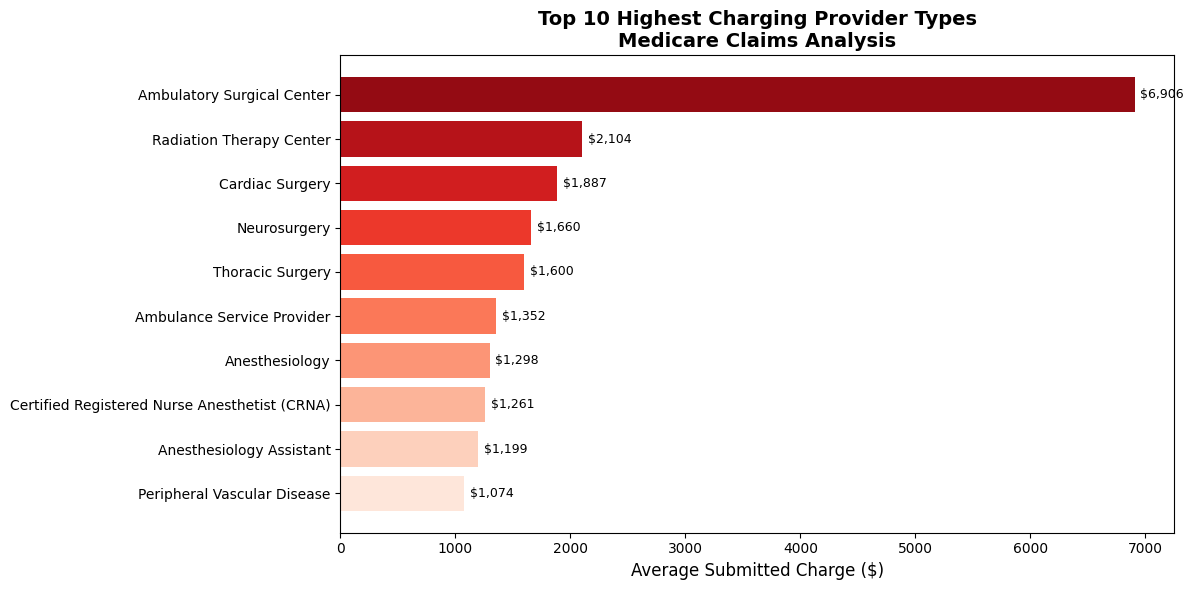

✅ Visual 1 saved


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette("Reds_r", len(result1))
bars = ax.barh(result1['Provider_Type'], result1['Avg_Charge'], color=colors)

ax.set_xlabel('Average Submitted Charge ($)', fontsize=12)
ax.set_title('Top 10 Highest Charging Provider Types\nMedicare Claims Analysis', 
             fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, result1['Avg_Charge']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../visuals/top_provider_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visual 1 saved")

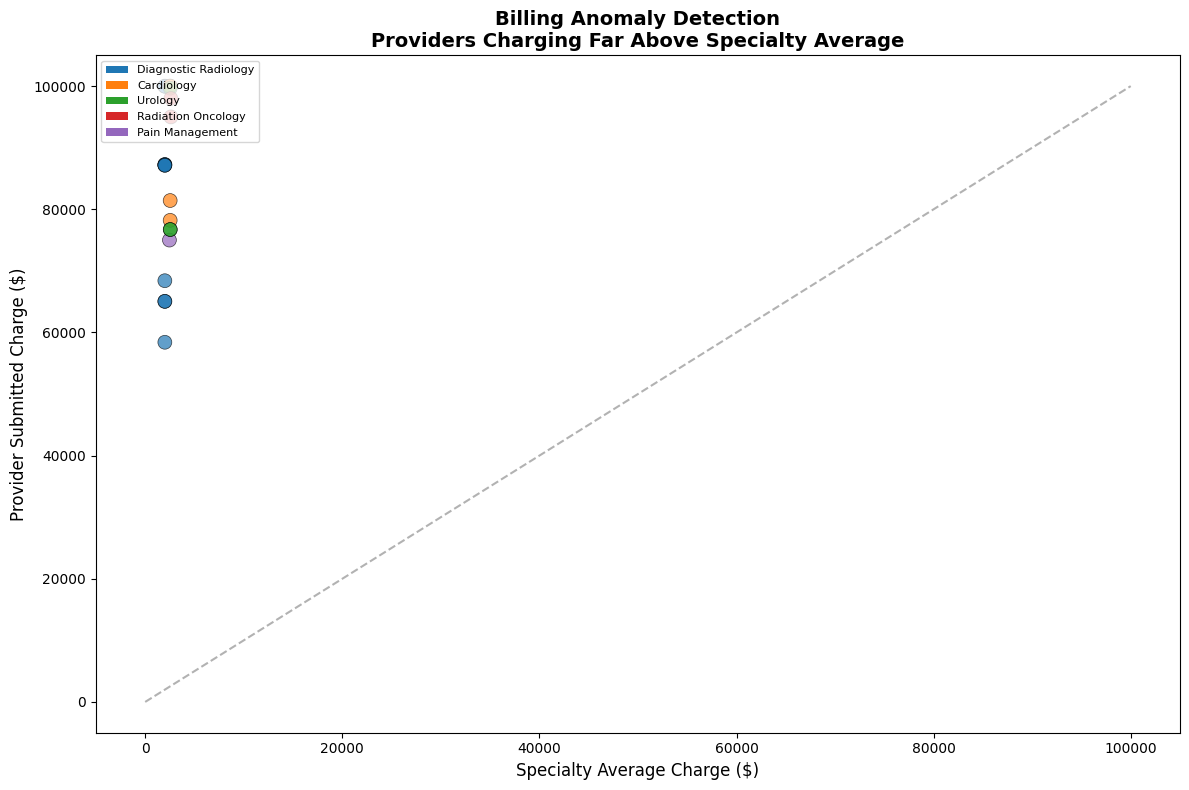

✅ Visual 2 saved


In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

# Color by provider type
provider_types = result2['Provider_Type'].unique()
palette = sns.color_palette("tab10", len(provider_types))
color_map = dict(zip(provider_types, palette))
colors = result2['Provider_Type'].map(color_map)

scatter = ax.scatter(result2['Specialty_Avg'], 
                     result2['Provider_Charge'],
                     c=colors,
                     s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add diagonal line = "normal" charging
max_val = result2['Provider_Charge'].max()
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Normal (1:1 ratio)')

ax.set_xlabel('Specialty Average Charge ($)', fontsize=12)
ax.set_ylabel('Provider Submitted Charge ($)', fontsize=12)
ax.set_title('Billing Anomaly Detection\nProviders Charging Far Above Specialty Average', 
             fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[pt], label=pt) for pt in provider_types]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../visuals/billing_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visual 2 saved")

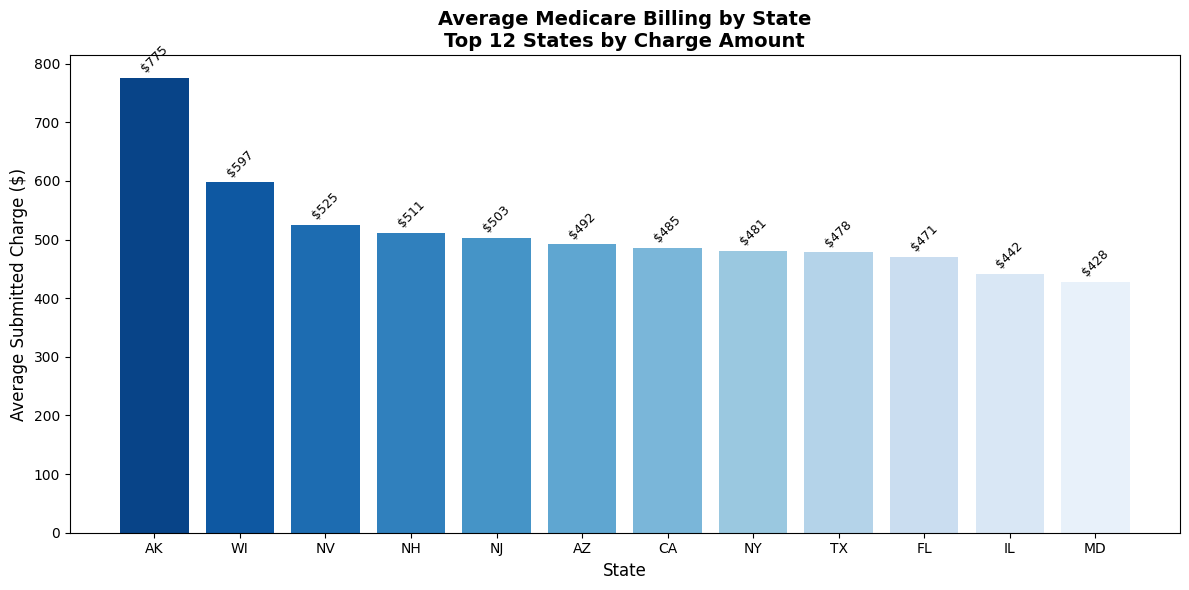

✅ Visual 3 saved


In [11]:
# Remove non-standard states
state_data = result3[~result3['State'].isin(['AS', 'ZZ', 'AE'])].head(12)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(state_data['State'], state_data['Avg_Charge'], 
              color=sns.color_palette("Blues_r", len(state_data)))

ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Average Submitted Charge ($)', fontsize=12)
ax.set_title('Average Medicare Billing by State\nTop 12 States by Charge Amount', 
             fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, val in zip(bars, state_data['Avg_Charge']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9, rotation=45)

plt.tight_layout()
plt.savefig('../visuals/state_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visual 3 saved")

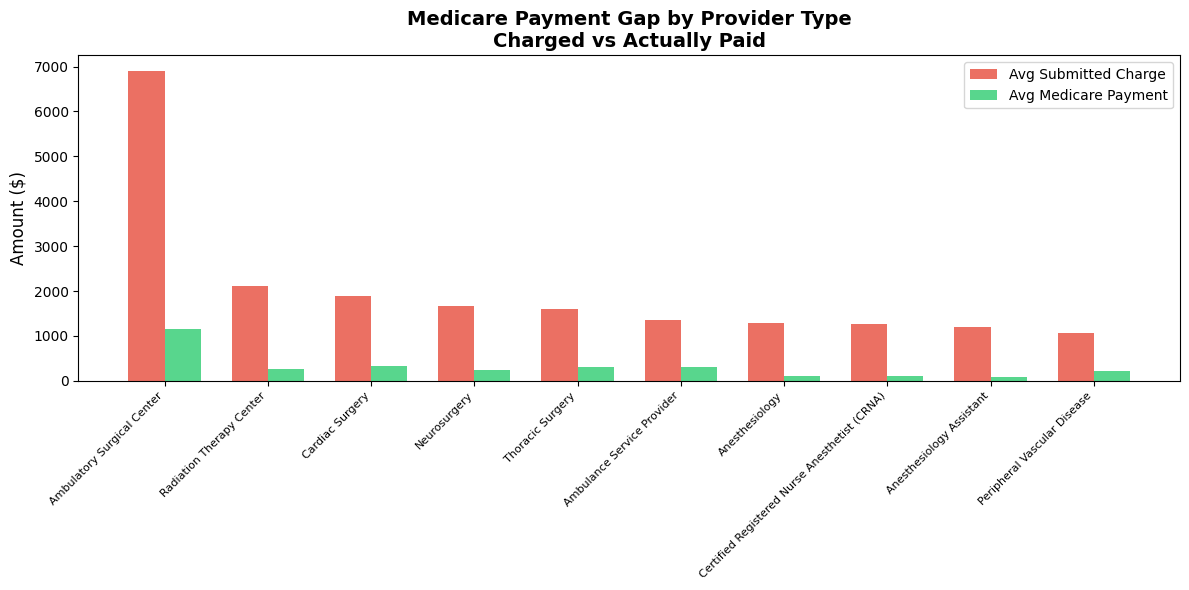

✅ Visual 4 saved


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(result1))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], result1['Avg_Charge'], 
               width, label='Avg Submitted Charge', color='#e74c3c', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], result1['Avg_Medicare_Paid'], 
               width, label='Avg Medicare Payment', color='#2ecc71', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(result1['Provider_Type'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_title('Medicare Payment Gap by Provider Type\nCharged vs Actually Paid', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../visuals/medicare_payment_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visual 4 saved")

In [13]:
# Print key findings to use in README
print("=== KEY FINDINGS FOR README ===")
print(f"\n1. Dataset: {df.shape[0]:,} Medicare claims records analyzed")
print(f"\n2. Highest charging specialty: {result1.iloc[0]['Provider_Type']} "
      f"at ${result1.iloc[0]['Avg_Charge']:,.2f} avg charge")
print(f"\n3. Biggest payment gap: {result1.iloc[0]['Provider_Type']} — "
      f"charged ${result1.iloc[0]['Avg_Charge']:,.2f} "
      f"but Medicare only paid ${result1.iloc[0]['Avg_Medicare_Paid']:,.2f}")
print(f"\n4. Most extreme anomaly: "
      f"{result2.iloc[0]['First_Name']} {result2.iloc[0]['Last_Name']} "
      f"({result2.iloc[0]['Provider_Type']}, {result2.iloc[0]['State']}) — "
      f"charged ${result2.iloc[0]['Provider_Charge']:,.2f} vs "
      f"specialty avg of ${result2.iloc[0]['Specialty_Avg']:,.2f} "
      f"({result2.iloc[0]['Charge_Ratio']}x above average)")
print(f"\n5. Highest avg charge state: {result3.iloc[0]['State']} "
      f"at ${result3.iloc[0]['Avg_Charge']:,.2f}")
print(f"\n6. Most billed service: {result4.iloc[0]['HCPCS_Desc'][:60]}... "
      f"with {result4.iloc[0]['Total_Services_Nationwide']:,.0f} total services")

=== KEY FINDINGS FOR README ===

1. Dataset: 9,660,647 Medicare claims records analyzed

2. Highest charging specialty: Ambulatory Surgical Center at $6,905.63 avg charge

3. Biggest payment gap: Ambulatory Surgical Center — charged $6,905.63 but Medicare only paid $1,164.02

4. Most extreme anomaly: Ryan Hickey (Diagnostic Radiology, NY) — charged $99,999.00 vs specialty avg of $1,995.72 (50.11x above average)

5. Highest avg charge state: AS at $1,444.67

6. Most billed service: Ground mileage, per statute mile... with 99,036,467 total services
